|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 7:</h2>|<h1>Modern vLLM<h1>|
|<h2>Section:</h2>|<h1>Tensor parallelism<h1>|
|<h2>Lecture:</h2>|<h1><b>Where to cut, and how few times the ranks have to talk<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Cut the model in half, twice

A model that does not fit on one card has to be split across several. The
question is where to cut, and the answer is decided entirely by how much
talking each cut requires.

Everything below runs on the CPU. The point is where the communication lands,
not the speed.

In [2]:
import torch

torch.manual_seed(0)
D, H = 256, 1024
x  = torch.randn(4, D)
W1 = torch.randn(D, H) / D**0.5      # up projection
W2 = torch.randn(H, D) / H**0.5      # down projection

reference = torch.relu(x @ W1) @ W2
print('one device:', tuple(reference.shape))

one device: (4, 256)


### Column parallel, then row parallel

Split the first matrix by **columns**: each rank owns some of the hidden
units and computes them independently. No communication, because `relu` is
elementwise and each hidden unit depends only on its own column.

Split the second by **rows**, matching. Each rank now holds a partial sum of
the full output, and adding them up is one all-reduce.

Column then row, and exactly one collective between them. Any other pairing
needs two.

In [3]:
RANKS = 2

W1_shards = list(W1.chunk(RANKS, dim=1))     # columns
W2_shards = list(W2.chunk(RANKS, dim=0))     # rows, matching

partials = []
for r in range(RANKS):
  h = torch.relu(x @ W1_shards[r])           # this rank's hidden units
  partials.append(h @ W2_shards[r])          # a PARTIAL output

out = sum(partials)                          # <- the one all-reduce

print('max difference from one device:', (out - reference).abs().max().item())
print(f'\nper rank: W1 {tuple(W1_shards[0].shape)}, W2 {tuple(W2_shards[0].shape)}')
print(f'each rank holds {100/RANKS:.0f}% of the weights')

max difference from one device: 0.0

per rank: W1 (256, 512), W2 (512, 256)
each rank holds 50% of the weights


### What it costs to talk

In [4]:
def traffic(batch, d_model, ranks, layers=32):
  """Bytes all-reduced per STEP, bf16. Grows with the batch."""
  return 2 * batch * d_model * 2 * (ranks-1)/ranks * layers

NVLINK, PCIE = 300e9, 12e9
STEP_MS = 10.0

print(f"{'batch':>6} {'ranks':>6} {'MB/step':>9} {'NVLink':>9} {'PCIe':>9} {'PCIe % of step':>15}")
for batch in (1, 32, 256):
  for r in (2, 8):
    b = traffic(batch, 4096, r)
    nv, pc = 1000*b/NVLINK, 1000*b/PCIE
    print(f'{batch:>6} {r:>6} {b/1e6:>9.2f} {nv:>8.3f}ms {pc:>8.3f}ms {100*pc/STEP_MS:>14.1f}%')

 batch  ranks   MB/step    NVLink      PCIe  PCIe % of step
     1      2      0.26    0.001ms    0.022ms            0.2%
     1      8      0.46    0.002ms    0.038ms            0.4%
    32      2      8.39    0.028ms    0.699ms            7.0%
    32      8     14.68    0.049ms    1.223ms           12.2%
   256      2     67.11    0.224ms    5.592ms           55.9%
   256      8    117.44    0.391ms    9.787ms           97.9%


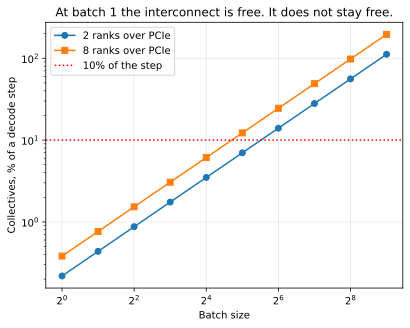

In [5]:
batches = np.array([1,2,4,8,16,32,64,128,256,512])
for r, style in ((2,'o-'), (8,'s-')):
  pcie = np.array([1000*traffic(b, 4096, r)/PCIE for b in batches])
  plt.plot(batches, 100*pcie/STEP_MS, style, label=f'{r} ranks over PCIe')
plt.axhline(10, color='r', ls=':', label='10% of the step')
plt.xscale('log', base=2); plt.yscale('log')
plt.xlabel('Batch size'); plt.ylabel('Collectives, % of a decode step')
plt.title('At batch 1 the interconnect is free. It does not stay free.')
plt.legend(); plt.grid(alpha=.3); plt.show()

### Read the direction of that line

At batch 1 an all-reduce is a few kilobytes and the interconnect does not
matter at all, even a slow one. Every plot in Part 2 said to raise the batch,
and the collectives grow with it linearly while the weight read does not.

So tensor parallelism and continuous batching pull against each other, and
the interconnect decides where they balance. That is why serving nodes are
sold with NVLink and why a rack of cards on PCIe is a different machine with
the same parts in it.

### Attention splits the same way, for a different reason

Heads are independent until the output projection, so give each rank whole
heads. Column-parallel on QKV, row-parallel on the output projection, one
all-reduce per block. Same shape, same single collective.

What you cannot do is split a head across ranks, because softmax is a
reduction over the whole row. That is the same constraint that made
split-K in stage 08c need a merge pass, one level up.

### And the thing to take away

Tensor parallelism is not a way to go faster. On one card's worth of work it
is strictly slower, because you added collectives to arithmetic that was
already fine. It is a way to run a model that does not fit, and the design
question is always the same: **how few times per layer do the ranks have to
talk?**

The answer is once, and the arrangement that achieves it is column then row.

Stage 20 makes you build it with real collectives, two ranks on one machine,
and checks that the 2-rank output matches the 1-rank output exactly.

    ./vc guide 20